# Polynomial Regression

- In this we make polynomial of every col with upto a set degree and then fit in the eqn of MultiLR
- Means we convert linear feature of data to Polynomial features
- Polynomial Reg is also a LR where y wrt to coef is linear
<img src='img10.png'></img>
- So if we have 2 cols, 1 is input and 1 is output and we set degree as 2, then we will have 3 input cols of x^0, x^1, x^2
- Means if degree(2), then every input cols will have 3 Polynomial cols
- Then eqn : y = B0 + B1.x^0 + B2.x^1 + B3.x^2
- If degree is more than req -> model will overfit the data
- If degree is less than req -> model will underfit data

- Using include_bias=False -> we can exclude x^0 term

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [2]:
# y = 0.8x^2 + 0.9x + 2
x = 6 * np.random.rand(200,1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200,1)

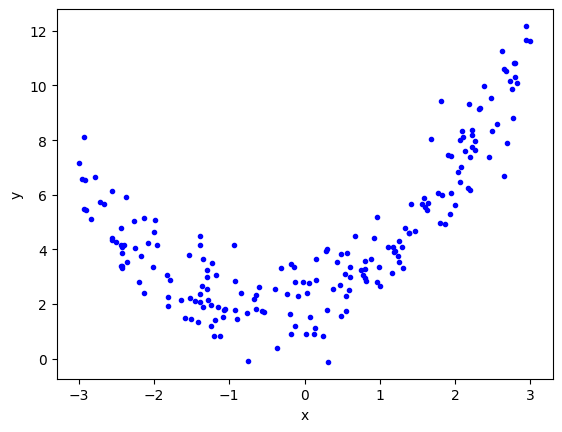

In [3]:
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [4]:
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y, test_size=0.2, random_state=2)

In [5]:
lr = LinearRegression()

In [6]:
lr.fit(x_tr, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = lr.predict(x_ts)
r2_score(y_ts, y_pred)

0.3306519131272472

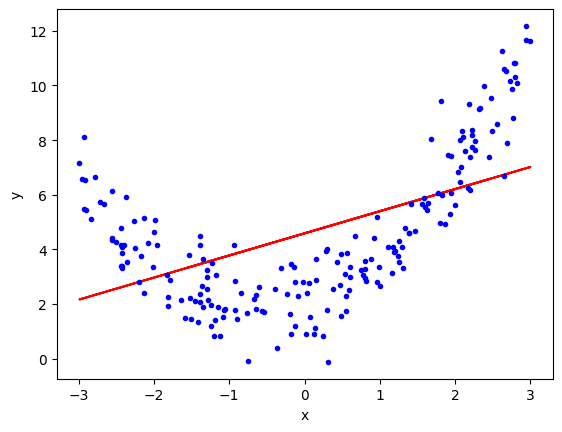

In [8]:
plt.plot(x_tr,lr.predict(x_tr),color='r')
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

- Applying Polynomial LR
- Degree = 2

In [18]:
poly = PolynomialFeatures(degree=2, include_bias=True)

x_tr_trans = poly.fit_transform(x_tr)
x_ts_trans = poly.transform(x_ts)

In [19]:
print(x_tr[0])
print(x_tr_trans[0])

[2.45052421]
[1.         2.45052421 6.00506893]


In [26]:
lr = LinearRegression()
lr.fit(x_tr_trans, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = lr.predict(x_ts_trans)

In [30]:
r2_score(y_ts, y_pred)

0.8845763337299785

In [31]:
print(lr.coef_)
print(lr.intercept_)

[[0.        0.8440395 0.7542206]]
[2.21083716]


In [32]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

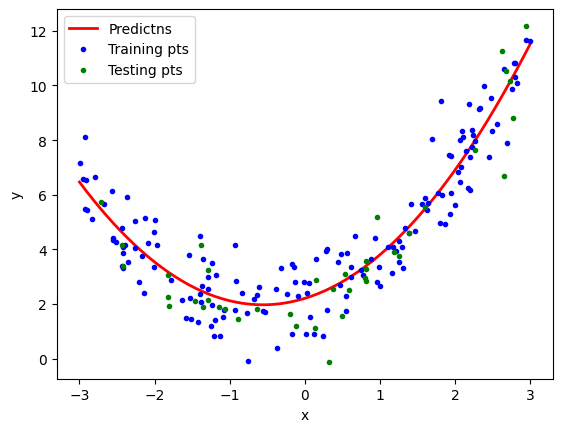

In [34]:
plt.plot(x_new,y_new, "r-", linewidth=2, label='Predictns')
plt.plot(x_tr,y_tr, "b.", label='Training pts')
plt.plot(x_ts,y_ts, "g.", label='Testing pts')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [35]:
def poly_reg(degree):
    x_new = np.linspace(-3,3,100).reshape(100,1)
    x_new_poly = poly.transform(x_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std = StandardScaler()
    lin_reg = LinearRegression()
    poly_reg = Pipeline([
        ("poly_featrs", polybig_features),
        ("std_scaler", std),
        ("lin_reg", lin_reg)
    ])
    poly_reg.fit(x,y)
    y_newbig = poly_reg.predict(x_new)
    plt.plot(x_new, y_newbig, 'r', label="Degree" + str(degree), linewidth=2)

    plt.plot(x_tr,y_tr, "b.", linewidth=3)
    plt.plot(x_ts,y_ts, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis([-3,3,0,10])
    plt.show()

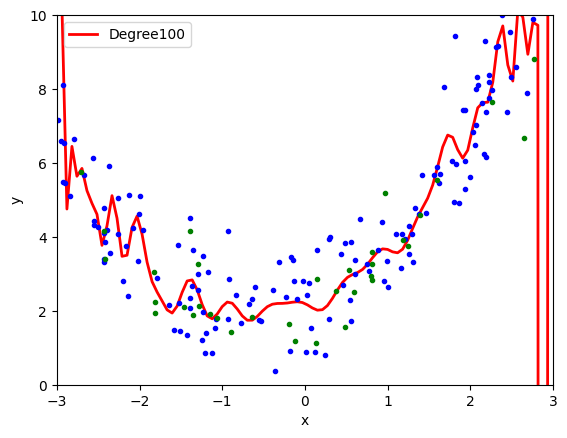

In [39]:
poly_reg(100)

- 3D polynomial reg

In [41]:
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1x*y + 2
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)

In [42]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [43]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1,100), yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

In [44]:
import plotly.graph_objects as go
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.show()

In [ ]:
x_multi = np.array()

# Bias Variance Trade-off

- The inability of ml model to truly capture a relationship in training data is called biased
- difference b/w fits on diff data Or differnce b/w error of training and test data
<img src='img11.png'>